In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

## **Background removal**

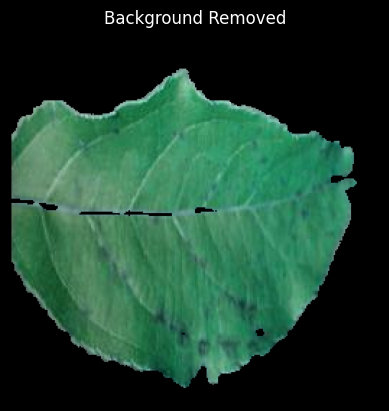

In [4]:
def remove_background_color(image_path):
    img = cv2.imread(image_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Green range
    lower = np.array([35, 40, 40])
    upper = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    result = cv2.bitwise_and(img, img, mask=mask)
    return result
img = remove_background_color(
    "../../data/train/Apple___Apple_scab/0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417_270deg.JPG")

plt.imshow(img)
plt.title("Background Removed")
plt.axis("off")
plt.show()

## **Contrast enhancement --CLAHE**

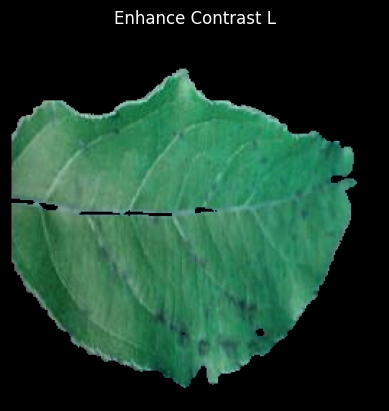

In [7]:
def enhance_contrast_l_channel(img):
    # Convert to LAB (L=Luminance)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L channel only
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)

    # Merge back and convert to BGR
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2BGR)
result_seg= enhance_contrast_l_channel(img)
plt.imshow(img)
plt.title("Enhance Contrast L")
plt.axis("off")
plt.show()

## **Mild sharpening**

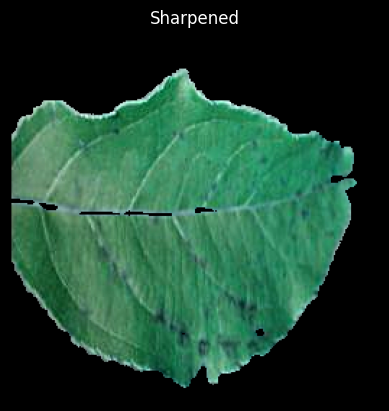

In [8]:
def sharpen(img):
    blurred = cv2.GaussianBlur(img, (0, 0), 3)
    sharpened = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
    return sharpened
img = sharpen(img)
plt.imshow(img)
plt.title("Sharpened")
plt.axis("off")
plt.show()

## **Normalization & standardization**

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# load with OpenCV
img = cv2.imread("../../data/train/Apple___Apple_scab/0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417_270deg.JPG")

# BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply transform (this line handles conversion)
img_tensor = transform(img)

print(img_tensor.shape)

torch.Size([3, 224, 224])
